## **Multilayer Perceptron using Backpropagation Algorithm**

Note: Please change the file directories to the directories of the respective files in your computer.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import time    # To monitor the computation time
from imblearn.over_sampling import SMOTE  # SMOTE to take care of the imbalance within the dataset
import random  # For randomly partitioning data

"""
    PRELIMINARIES.
    Loading the dataset and splitting them into training and validation with SMOTE applied.
"""

# Read the data.csv file using CSV
with open(r"data.csv") as data_csv:  # Change the directory here to that of data.csv in your computer
     data_list = list(csv.reader(data_csv, dialect = "excel"))

data = np.array(data_list, dtype = float)  # Load into a numpy array (faster)

# Read the data_labels file using CSV
with open(r"data_labels.csv") as data_labels_csv:  # Change the directory here to that of data_labels.csv in your computer
    data_labels_list = list(csv.reader(data_labels_csv, dialect = "excel"))

data_labels = np.array(data_labels_list, dtype = int)  # Load into a numpy array

# Transform the dataset according to Synthetic Minority Oversampling Techniqe (SMOTE)
oversample = SMOTE()
data, data_labels = oversample.fit_resample(data, data_labels)

# Create a dataframe of the data and labels so that we are sure that each label corresponds to the correct data
# The last column of the dataframe contains the labels
dataframe = np.column_stack((data, data_labels))

# Shuffle the order of the dataset (with labels)
random.shuffle(dataframe)

# Split the dataset into training and validation set 
validation_set = dataframe[:800, :dataframe.shape[1]-1]
with open("validation_set.csv", "w") as validation_set_data:  # Save into a csv file
    writer = csv.writer(validation_set_data)
    writer.writerows(validation_set)

validation_labels = dataframe[:800, -1]
with open("validation_labels.csv", "w") as validation_labels_data:  # Save into a csv file
    writer = csv.writer(validation_labels_data)
    for label in validation_labels:
        writer.writerow([label])

training_set = dataframe[800:, :dataframe.shape[1]-1]
with open("training_set.csv", "w") as training_set_data:  # Save into a csv file
    writer = csv.writer(training_set_data)
    writer.writerows(training_set)

training_labels = dataframe[800:, -1]
with open("training_labels.csv", "w") as training_labels_data:  # Save into a csv file
    writer = csv.writer(training_labels_data)
    for label in training_labels:
        writer.writerow([label])

In [47]:
"""
    ACTIVATION FUNCTIONS.
    Logistic, tanh, and ReLU functions.
    
"""

def Logistic(v):
    """
       Function that returns the value of the sigmoid of the neuron. 
       Input: a, arbitrary constant
              v, neuron activity
    """
    a = 2.0
    return 1/(1 + np.exp(-a*v))

def LogisticPrime(v):
    """
       Function that returns the value of the derivative of the sigmoid of the neuron. 
       Input: v, neuron activity
    """
    a = 2.0
    return a * Logistic(v) * (1 - Logistic(v))

def Tanh(v):
    """
       Function that returns the value of the tanh of the neuron. 
       Input: v, neuron activity
    """
    a = 1.716
    b = 2/3
    return a * np.tanh(b*v)

def TanhPrime(v):
    """
       Function that returns the value of the derivative of the tanh of the neuron. 
       Input: v, neuron activity
    """
    a = 1.716
    b = 2/3
    return (a*b) * (1 - Tanh(v)**2)

def LeakyReLU(v):
    """
       Function that returns the value of the leaky rectified linear activation of the neuron.
       Input: alpha, threshold 
                  v, neuron activity
    """
    alpha = 0.01
    return np.where(v > 0, v, alpha * v) + 10e-06  # Add a very small number to avoid NaN

def LeakyReLUPrime(v):
    """
       Function that returns the value of the derivative of the leaky rectified linear activation of the neuron.
       Input: alpha, threshold 
                  v, neuron activity
    """
    alpha = 0.01
    return np.where(v > 0, 1.0, alpha) + 10e-06  # Add a very small number to avoid NaN


"""
    OTHER FUNCTIONS.
    Functions to decode one-hot encoded outputs and for computation of metrics.
"""

# Decode one-hot encoded labels
def Decode(labels):
    """
        Function that decodes one-hot encoded outputs.
        Input: labels, list of encoded labels
    """
    labels = np.array(labels)
    decoded = []
    for label in labels:
        decoded.append(np.argmax(label))
    return decoded

# Decode a single label
def DecodeLabel(label):
    return np.argmax(label)
    

# Compute for the metrics
def Metrics(y_predicted, y_true):
    """
        Function that generates the confusion matrix and calculates the metrics accuracy, precision, recall, F1 score, and MCC.
        Input: y_predicted, list of predicted class labels
               y_true, list of true class labels
    """

    N_classes = len(np.unique(y_true)) + 1

    # Construct confusion matrix
    confusion_matrix = np.zeros((N_classes, N_classes))
    for true, pred in zip(y_true, y_predicted):  
        confusion_matrix[true, pred] += 1  # Plus 1 when they are equal

    # Compute for precision, recall
    precision = np.zeros(N_classes)
    recall = np.zeros(N_classes)
    for i in range(N_classes):
        precision[i] = confusion_matrix[i, i] / (np.sum(confusion_matrix[:, i]) + 10e-06)  # Add a very small number to avoid division by zero
        recall[i] = confusion_matrix[i, i] / (np.sum(confusion_matrix[i, :]) + 10e-06)

    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)

    # Calculate F1 Score 
    f1 = 2 * (macro_precision * macro_recall) / (macro_precision + macro_recall + 10e-06)

    # Compute for accuracy
    accuracy = np.sum(np.diag(confusion_matrix)) / np.sum(confusion_matrix)

    # Calculate Matthew's Correlation Coefficient
    mcc = (2 * (macro_precision * macro_recall) - 1) / (np.sqrt((macro_precision + 1) * (macro_recall + 1)))

    return {"Accuracy": accuracy.round(4), "Precision": macro_precision.round(4), "Recall": macro_recall.round(4),"F1 Score": f1.round(4), "MCC": mcc.round(4), "Confusion Matrix": confusion_matrix}
    
    

"""
    MULTILAYER PERCEPTRON.
    Feed-forward, backpropagate, and train the multilayer perceptron.
"""

class MultiLayerPerceptron():
    def __init__(self, eta, alpha, batch_size, X, Y, X_val, Y_val, hidden_dim1, hidden_dim2, output_dim, activation_function, activation_function_prime):
        self.eta = eta  # Learning rate parameter
        self.alpha = alpha  # Momentum constant in weight update
        self.batch_size = batch_size
        self.X = X
        self.Y = np.squeeze(np.eye(9)[Y.astype(int).reshape(-1)])  # One-hot encoded training labels
        self.X_val = X_val
        self.Y_val = np.squeeze(np.eye(9)[Y_val.astype(int).reshape(-1)])  # One-hot encoded validation label
        
        # Dimensions of the input, hidden layer 1, hidden layer 2, and output
        self.input_dim = self.X.shape[1]
        self.hidden_dim1 = hidden_dim1
        self.hidden_dim2 = hidden_dim2
        self.output_dim = output_dim

        # Define the activation functions to be used
        self.activation_function = activation_function
        self.activation_function_prime = activation_function_prime

        # Initialize the weights as random numbers from 0, 1
        np.random.seed()
        self.weights1 = np.random.rand(self.input_dim, hidden_dim1)  # Weights from input to first hidden layer
        self.weights2 = np.random.rand(hidden_dim1, hidden_dim2)  # Weights from first hidden layer to second hidden layer
        self.weights3 = np.random.rand(hidden_dim2, output_dim)  # Weights from hidden layer 2 to output

        # Initialize the bias terms to be equal to zero
        self.bias1 = np.zeros((1, hidden_dim1))
        self.bias2 = np.zeros((1, hidden_dim2))
        self.bias3 = np.zeros((1, output_dim))  

        self.training_loss = list()
        self.validation_loss = list()
        self.training_time = list()
        self.outputs = list()  # List of predicted outputs
        
    def FeedForward(self, inputs):
        """
            Function that performs forward propagation from the input, through the hidden layers, and output
        """
        # Propagate from input layer to hidden layer 1
        self.hidden_layer1 = np.dot(inputs, self.weights1) + self.bias1  
        self.hidden_layer1_activate = self.activation_function(self.hidden_layer1)

        # Propagate from hidden layer 1 to hidden layer 2
        self.hidden_layer2 = np.dot(self.hidden_layer1, self.weights2) + self.bias2  
        self.hidden_layer2_activate = self.activation_function(self.hidden_layer2)

        # Propagate from hidden layer 2 to output
        self.output_layer = np.dot(self.hidden_layer2, self.weights3) + self.bias3  # Propagate from hidden layer 2 to output
        outputs = Logistic(self.output_layer)

        return outputs  
  
    def Backpropagate(self, X_train, Y_train, outputs):
        """
            Function that performs backpropagation by updating the weights using local gradient.
        """
        # Local gradient of output layer
        delta_weights3 = (outputs - Y_train) * LogisticPrime(outputs)
        # Local gradients of hidden layer 2
        delta_weights2 = np.dot(delta_weights3, self.weights3.T) * self.activation_function_prime(self.hidden_layer2_activate)
        # Local gradients of hidden layer 1
        delta_weights1 = np.dot(delta_weights2, self.weights2.T) * self.activation_function_prime(self.hidden_layer1_activate)
       
        # Weight and bias updates with a momentum term to speed up computation
        self.weights3 = self.alpha * self.weights3 - self.eta * np.dot(self.hidden_layer2_activate.T, delta_weights3)
        self.bias3 -= self.eta * np.sum(delta_weights3, axis = 0, keepdims = True)

        self.weights2 = self.alpha * self.weights2 - self.eta * np.dot(self.hidden_layer1_activate.T, delta_weights2)
        self.bias2 -= self.eta * np.sum(delta_weights2, axis = 0, keepdims = True)
        
        self.weights1 = self.alpha * self.weights1 - self.eta * np.dot(X_train.T, delta_weights1)
        self.bias1 -= self.eta * np.sum(delta_weights1, axis = 0, keepdims = True)  
  
    def Train(self, epochs, batch_size):
        inputs = self.X
        targets = self.Y
        training_errors = []
        validation_errors = []
        start = time.time()
        # Train for specified number of epochs
        for epoch in range(epochs):
            loss = 0
            for i in range(0, len(inputs), batch_size):  # Perform per batch 
                batch_inputs = inputs[i: i + batch_size]
                batch_targets = targets[i: i + batch_size]
                outputs = self.FeedForward(batch_inputs)
                self.Backpropagate(batch_inputs, batch_targets, outputs)
                loss += np.sum(np.square(batch_targets - outputs) / batch_size)
            self.training_loss.append(loss)
        
            # Calculate validation error
            validation_inputs = self.X_val  
            validation_targets = self.Y_val
            outputs_val = self.FeedForward(validation_inputs)  
            validation_error = np.sum(np.square(validation_targets - outputs_val))  
            self.validation_loss.append(validation_error)
            self.outputs.append(outputs_val)
        # Training time  
        end = time.time()
        self.training_time.append(np.round(end - start, 4))  

    def Predict(self, inputs):
        """
            Function that predicts the class of a set of inputs.
        """
        return Decode(self.FeedForward(inputs))  # decode the labels

**Network A**

C:\Users\Reign\AppData\Local\Temp\ipykernel_10944\543264625.py:14: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-a*v))


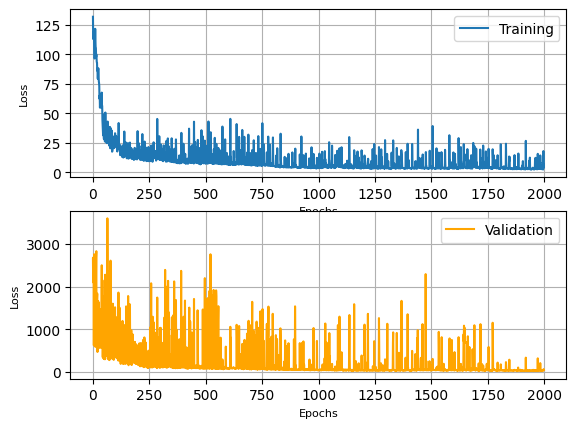

Total training time of Network A for 2000 epochs: 1195.886 
for eta = 0.0005, hidden layer 1 dim = 128, hidden layer 2 dim = 128, alpha = 1.0, and batch_size = 200


In [3]:
# Define the training set and validation set
X_train = training_set
Y_train = training_labels

X_val = validation_set
Y_val = validation_labels

# Initialize the parameters to be used
epochs = 2000 # number of times we'll iterate over all training set
eta = 0.0005  # learning rate
alpha = 1.0  # momentum constant
batch_size = 200  # number of samples to be processed by batch

hidden_dim1 = 128  # number of neurons in first hidden layer 
hidden_dim2 = 128  # number of neurons in second hidden layer
output_dim = 8 + 1 # number of neurons in output layer (+1 because encoding is from indices 0 to 8)

# Activation functions to be used
activation_functions = {"1": Logistic, "2": Tanh, "3": LeakyReLU}  # dictionary of pre-defined activation functions
activation_functions_prime = {"1": LogisticPrime, "2": TanhPrime, "3": LeakyReLUPrime}  # dictionary of pre-defined derivative of activation functions
    
activation_function = "2"  # Change this according the desired activation function

NetworkA = MultiLayerPerceptron(eta, alpha, batch_size, X_train, Y_train, X_val, Y_val, hidden_dim1, hidden_dim2, output_dim, activation_functions[activation_function], activation_functions_prime[activation_function])
NetworkA.Train(epochs, batch_size)

# Plot the learning curve of Network A
plt.subplot(2, 1, 1)
plt.plot(NetworkA.training_loss, label = "Training")
plt.xlabel("Epochs", fontsize = 8)
plt.ylabel("Loss", fontsize = 8)
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(NetworkA.validation_loss, label = "Validation", color = "orange")
plt.xlabel("Epochs", fontsize = 8)
plt.ylabel("Loss", fontsize = 8)
plt.grid()
plt.legend()

plt.savefig("learning_curveA.png")
plt.show()

# Display training time
train_time_NetworkA = np.mean(NetworkA.training_time)  # Of all epochs
print(f"Total training time of Network A for {epochs} epochs: {np.round(train_time_NetworkA, 4)} \nfor eta = {eta}, hidden layer 1 dim = {hidden_dim1}, hidden layer 2 dim = {hidden_dim2}, alpha = {alpha}, and batch_size = {batch_size}")


# Use the network on a test set
# Load the test set
with open(r"test_set.csv") as test_csv:
    test_list = list(csv.reader(test_csv, dialect = "excel"))
    
test_set = np.array(test_list, dtype = "float")
X_test = test_set

# Network A: tanh-tanh-logistic
activation_function = "2"

predicted_NetworkA = np.array(NetworkA.Predict(X_test))

# Save prediction of Network A into a csv file
with open("predictions_for_test_tanh.csv", "w") as a:  # Save into a csv file
    writer = csv.writer(a)
    for label in predicted_NetworkA:
        writer.writerow([label])

C:\Users\Reign\AppData\Local\Temp\ipykernel_10944\543264625.py:14: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-a*v))


{'Accuracy': np.float64(0.965), 'Precision': np.float64(0.8613), 'Recall': np.float64(0.8602), 'F1 Score': np.float64(0.8607), 'MCC': np.float64(0.2589), 'Confusion Matrix': array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  5., 350.,   1.,   0.,   0.,   0.,   0.,   0.,   1.],
       [  0.,   0.,  34.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,  16.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0., 141.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,  68.,   0.,   0.,   0.],
       [  8.,   0.,   1.,   0.,   0.,   0.,  63.,   0.,   1.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.,   0.],
       [  2.,   1.,   7.,   0.,   0.,   0.,   1.,   0.,  97.]])}


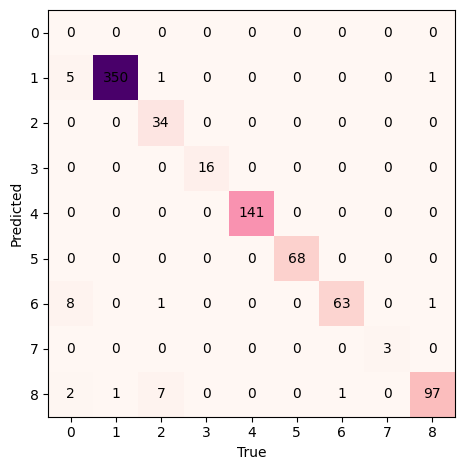

In [4]:
# Metrics of Network A
metricsA = Metrics(np.array(NetworkA.Predict(X_val)), Y_val.astype(int))
print(metricsA)

# Display confusion matrix
confusion_matrixA = metricsA["Confusion Matrix"]
plt.imshow(confusion_matrixA, cmap = "RdPu")
for i in range(len(confusion_matrixA)):
    for j in range(len(confusion_matrixA)):
        plt.text(j, i, str(int(confusion_matrixA[i, j])), ha = "center", va = "center", color = "black")

plt.xlabel("True")
plt.ylabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrixA.png")
plt.show()

**Network B**

C:\Users\Reign\AppData\Local\Temp\ipykernel_10944\2954036302.py:14: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-a*v))


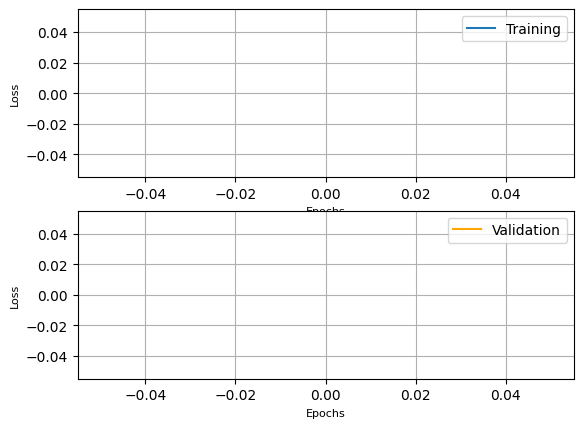

Total training time of Network B for 2000 epochs: 463.3707 
for eta = 0.05, hidden layer 1 dim = 128, hidden layer 2 dim = 128, alpha = 1.0, and batch_size = 200


In [48]:
# Define the training set and validation set
X_train = training_set
Y_train = training_labels

X_val = validation_set
Y_val = validation_labels

# Initialize the parameters to be used
epochs = 2000 # number of times we'll iterate over all training set
eta = 0.05  # learning rate
alpha = 1.0  # momentum constant
batch_size = 200  # number of samples to be processed by batch

hidden_dim1 = 128  # number of neurons in first hidden layer 
hidden_dim2 = 128  # number of neurons in second hidden layer
output_dim = 8 + 1 # number of neurons in output layer (+1 because encoding is from indices 0 to 8)

# Activation functions to be used
activation_functions = {"1": Logistic, "2": Tanh, "3": LeakyReLU}  # dictionary of pre-defined activation functions
activation_functions_prime = {"1": LogisticPrime, "2": TanhPrime, "3": LeakyReLUPrime}  # dictionary of pre-defined derivative of activation functions
    
activation_function = "3"  # Change this according the desired activation function

NetworkB = MultiLayerPerceptron(eta, alpha, batch_size, X_train, Y_train, X_val, Y_val, hidden_dim1, hidden_dim2, output_dim, activation_functions[activation_function], activation_functions_prime[activation_function])
NetworkB.Train(epochs, batch_size)

# Plot the learning curve of Network A
plt.subplot(2, 1, 1)
plt.plot(NetworkB.training_loss, label = "Training")
plt.xlabel("Epochs", fontsize = 8)
plt.ylabel("Loss", fontsize = 8)
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(NetworkB.validation_loss, label = "Validation", color = "orange")
plt.xlabel("Epochs", fontsize = 8)
plt.ylabel("Loss", fontsize = 8)
plt.grid()
plt.legend()

plt.savefig("learning_curveB.png")
plt.show()

# Display training time
train_time_NetworkB = np.mean(NetworkB.training_time)  # Of all epochs
print(f"Total training time of Network B for {epochs} epochs: {np.round(train_time_NetworkB, 4)} \nfor eta = {eta}, hidden layer 1 dim = {hidden_dim1}, hidden layer 2 dim = {hidden_dim2}, alpha = {alpha}, and batch_size = {batch_size}")


# Use the network on a test set
# Load the test set
with open(r"test_set.csv") as test_csv:
    test_list = list(csv.reader(test_csv, dialect = "excel"))
    
test_set = np.array(test_list, dtype = "float")
X_test = test_set


# Network B: leakyrelu-leakyrelu-logistic
activation_function = "3"

predicted_NetworkB = np.array(NetworkB.Predict(X_test))

# Save prediction of Network B into a csv file
with open("predictions_for_test_leakyrelu.csv", "w") as b:  # Save into a csv file
    writer = csv.writer(b)
    for label in predicted_NetworkB:
        writer.writerow([label])

{'Accuracy': np.float64(0.0), 'Precision': np.float64(0.0), 'Recall': np.float64(0.0), 'F1 Score': np.float64(0.0), 'MCC': np.float64(-1.0), 'Confusion Matrix': array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [357.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [ 34.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [ 16.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [141.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [ 68.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [ 73.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  3.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [108.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]])}


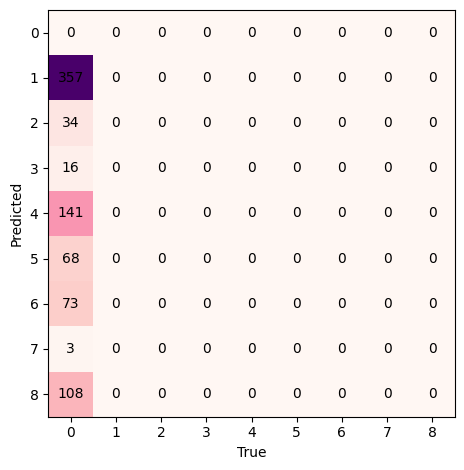

In [49]:
# Metrics of Network B
metricsB = Metrics(np.array(NetworkB.Predict(X_val)), Y_val.astype(int))
print(metricsB)

# Display confusion matrix
confusion_matrixB = metricsB["Confusion Matrix"]
plt.imshow(confusion_matrixB, cmap = "RdPu")
for i in range(len(confusion_matrixB)):
    for j in range(len(confusion_matrixB)):
        plt.text(j, i, str(int(confusion_matrixB[i, j])), ha = "center", va = "center", color = "black")

plt.xlabel("True")
plt.ylabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrixB.png")
plt.show()